# Neural Networks — MLPClassifier (sklearn)

**Learning Objectives:**
- Train an MLP (Multi-Layer Perceptron) classifier using sklearn
- Visualize the loss curve to diagnose convergence
- Compare different hidden layer architectures
- Understand the effect of learning rate

**Dataset:** Pima Indians Diabetes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
import numpy as np

seed = 42

Neural networks use gradient descent — scaling features is essential.

In [2]:
df = pd.read_csv('data/diabetes.csv')

train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['Outcome'], axis=1)
y_train = train_set['Outcome']
X_test = test_set.drop(['Outcome'], axis=1)
y_test = test_set['Outcome']

scaler = MinMaxScaler()
features_names = X_train.columns

X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=features_names)

X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=features_names)

### MLPClassifier — Default

Default architecture: one hidden layer with 100 neurons.

In [3]:
mlp_default = MLPClassifier(random_state=seed, max_iter=500)
mlp_default.fit(X_train, y_train)
y_pred = mlp_default.predict(X_test)

print(f'MLPClassifier (default):')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Converged: {mlp_default.n_iter_ < mlp_default.max_iter}')

MLPClassifier (default):
  Accuracy:  0.7544
  Precision: 0.7963
  Converged: True


### Loss Curve

Plot training loss over iterations to check convergence.

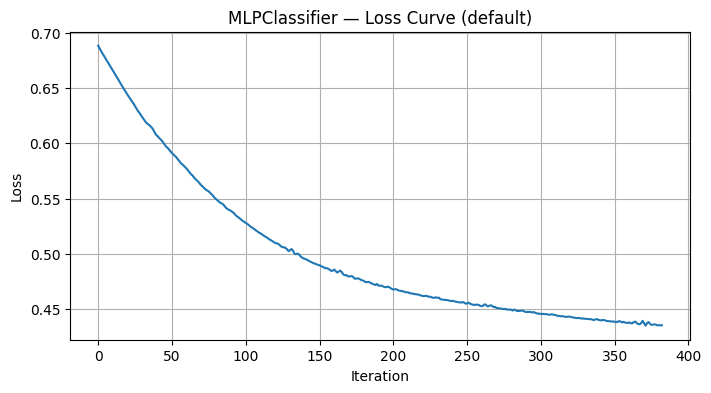

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_default.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLPClassifier — Loss Curve (default)')
plt.grid(True)
plt.show()

### Compare Architectures

Different hidden layer structures:
- `(50,)` — single layer, 50 neurons
- `(100, 50)` — two hidden layers (deep but narrow)
- `(10, 5)` — two small layers (limited capacity)

In [5]:
architectures = [
    ('(50,)', (50,)),
    ('(100, 50)', (100, 50)),
    ('(10, 5)', (10, 5)),
]

results = []

for name, arch in architectures:
    mlp = MLPClassifier(hidden_layer_sizes=arch, random_state=seed, max_iter=500)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    results.append({'architecture': name, 'accuracy': acc, 'precision': prec, 'iterations': mlp.n_iter_})

results_df = pd.DataFrame(results)
print(results_df)

/home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  architecture  accuracy  precision  iterations
0        (50,)  0.763158   0.800000         500
1    (100, 50)  0.728070   0.784314         494
2      (10, 5)  0.692982   0.755102         500


/home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Effect of Learning Rate

Fixed architecture `(50,)` with different `learning_rate_init` values.

In [6]:
lrs = [0.1, 0.01, 0.001]
lr_results = []

for lr in lrs:
    mlp = MLPClassifier(hidden_layer_sizes=(50,), learning_rate_init=lr, random_state=seed, max_iter=500)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    lr_results.append({'learning_rate': lr, 'accuracy': acc, 'iterations': mlp.n_iter_})

lr_df = pd.DataFrame(lr_results)
print(lr_df)

   learning_rate  accuracy  iterations
0          0.100  0.745614          61
1          0.010  0.745614         149
2          0.001  0.763158         500


/home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Parameter Notes — MLPClassifier

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `hidden_layer_sizes` | (100,) | Neurons per hidden layer. More layers/neurons → more capacity. | (50,), (100,), (100, 50) |
| `activation` | 'relu' | Activation function: 'relu', 'tanh', 'logistic'. | 'relu', 'tanh' |
| `solver` | 'adam' | Weight optimizer: 'adam', 'sgd', 'lbfgs'. | 'adam', 'sgd' |
| `alpha` | 0.0001 | L2 regularization strength. Higher → more regularization. | 0.0001–0.01 |
| `learning_rate` | 'constant' | LR schedule: 'constant', 'invscaling', 'adaptive'. | 'constant', 'adaptive' |
| `learning_rate_init` | 0.001 | Initial learning rate. Too high → unstable, too low → slow. | 0.001–0.1 |
| `max_iter` | 200 | Maximum iterations. Increase if not converging. | 200–1000 |
| `batch_size` | 'auto' | Minibatch size (auto = 200 for adam/sgd). | 'auto', 32, 64, 128 |

**Key trade-offs:**
- More hidden layers/neurons → higher capacity, risk of overfitting
- `learning_rate` too high → loss diverges; too low → slow convergence
- Feature scaling is **essential** — NNs use gradient descent
- `max_iter` may need increasing for complex datasets

## Exercises — Sonar Dataset

Apply MLP to the Sonar (Mines vs. Rocks) dataset.
Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

In [7]:
df_sonar = pd.read_csv('data/sonar_data.csv')
df_sonar.head()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [8]:
df_sonar.describe()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,...,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.029208,0.038443,0.043837,0.054053,0.075105,0.104599,0.121591,0.134677,0.177361,0.208245,...,0.016034,0.013472,0.010729,0.010917,0.009300,0.008181,0.007771,0.007947,0.007936,0.006523
std,0.023038,0.033040,0.038521,0.046583,0.055669,0.059247,0.061897,0.085340,0.118311,0.134741,...,0.012027,0.009628,0.007071,0.007310,0.007103,0.005719,0.005756,0.006485,0.006196,0.005038
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013300,0.016400,0.018900,0.024450,0.037700,0.066950,0.080600,0.080350,0.096750,0.111150,...,0.008350,0.007350,0.005050,0.005350,0.004100,0.004400,0.003700,0.003600,0.003650,0.003100
50%,0.022800,0.030800,0.034200,0.044100,0.062000,0.092100,0.105600,0.111900,0.152200,0.181000,...,0.013800,0.011500,0.009600,0.009300,0.007500,0.006800,0.005900,0.005800,0.006300,0.005300
75%,0.035800,0.048100,0.058200,0.065700,0.101050,0.134150,0.153050,0.169800,0.231500,0.269000,...,0.020700,0.016750,0.014900,0.014450,0.012100,0.010350,0.010350,0.010400,0.010350,0.008550
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [9]:
# TODO: split, scale features, train MLP with different architectures,
# plot loss curve, compare accuracy and precision.
# Try at least two architectures and two learning rates.